# Ionic Scattering Factors Test

This notebook tests the implementation of ionic scattering factors from the Peng parametrization.
It compares the electron wave function after scattering on neutral Ca vs Ca2+ ions,
and visualizes scattering factors across different parametrizations.

In [1]:
%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.atoms import Atoms
import abtem
from abtem.parametrizations import (
    PengParametrization,
    LobatoParametrization,
    KirklandParametrization,
)

# Configuration
abtem.config.set({
    'device': 'gpu',
    'precision': 'float64',
})

energy = 60e3    # eV
alpha = 1        # mrad
L = 500          # Angstrom (supercell size)
sampling = 0.1   # Angstrom

## 1. Compare Scattering Factors

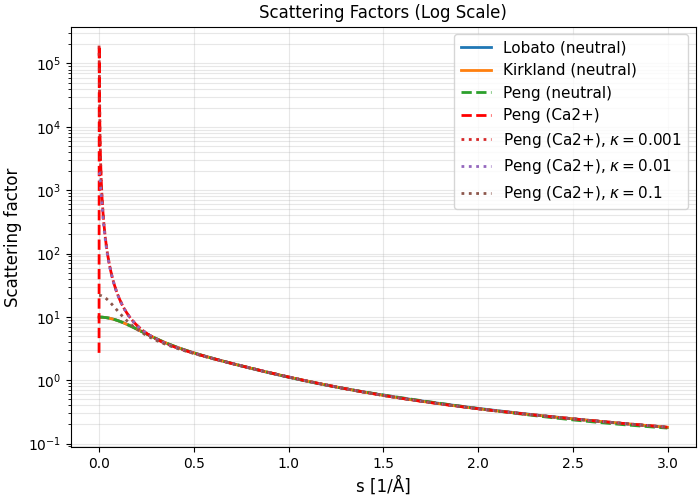

In [5]:
# Create parametrizations
lobato = LobatoParametrization()
kirkland = KirklandParametrization()
peng_neutral = PengParametrization('peng_high.json')
peng_ionic = PengParametrization('peng_ionic.json')

# Get scattering factors for Ca (neutral) and Ca2+ (ionic)
sampling_s = 1 / (2*L)
f_lobato_ca = lobato.line_profiles('Ca', cutoff=3, sampling=sampling_s, name='scattering_factor')
f_kirkland_ca = kirkland.line_profiles('Ca', cutoff=3, sampling=sampling_s, name='scattering_factor')
f_peng_ca_neutral = peng_neutral.line_profiles('Ca', cutoff=3, sampling=sampling_s, name='scattering_factor')
f_peng_ca_ionic = peng_ionic.line_profiles('Ca', charge=2.0, cutoff=3, sampling=sampling_s, name='scattering_factor')
f_peng_ca_ionic_kappa1em3 = peng_ionic.line_profiles('Ca', charge=2.0, cutoff=3, sampling=sampling_s, kappa=0.001, name='scattering_factor')
f_peng_ca_ionic_kappa1em2 = peng_ionic.line_profiles('Ca', charge=2.0, cutoff=3, sampling=sampling_s, kappa=0.01, name='scattering_factor')
f_peng_ca_ionic_kappa1em1 = peng_ionic.line_profiles('Ca', charge=2.0, cutoff=3, sampling=sampling_s, kappa=0.1, name='scattering_factor')
#f_peng_ca_ionic_Lcell = peng_ionic.line_profiles('Ca', charge=2.0, cutoff=3, sampling=sampling_s, regularization='rozzi_spherical', L_cell=L, name='scattering_factor')

fig, ax = plt.subplots(1, figsize=(7, 5), layout='constrained')

s = f_lobato_ca.axes_metadata[1].coordinates(f_lobato_ca.shape[-1])

ax.semilogy(s, f_lobato_ca.array[0, :], label='Lobato (neutral)', linewidth=2)
ax.semilogy(s, f_kirkland_ca.array[0, :], label='Kirkland (neutral)', linewidth=2)
ax.semilogy(s, f_peng_ca_neutral.array[0, :], label='Peng (neutral)', linewidth=2, linestyle='--')
ax.semilogy(s, f_peng_ca_ionic.array[0, :], label='Peng (Ca2+)', linewidth=2, linestyle='--', color='red')
ax.semilogy(s, f_peng_ca_ionic_kappa1em3.array[0, :], label=r'Peng (Ca2+), $\kappa = 0.001$', linewidth=2, linestyle=':')
ax.semilogy(s, f_peng_ca_ionic_kappa1em2.array[0, :], label=r'Peng (Ca2+), $\kappa = 0.01$', linewidth=2, linestyle=':')
ax.semilogy(s, f_peng_ca_ionic_kappa1em1.array[0, :], label=r'Peng (Ca2+), $\kappa = 0.1$', linewidth=2, linestyle=':')
#ax.semilogy(s, f_peng_ca_ionic_Lcell.array[0, :], label=fr'Peng (Ca2+), $L_{{\text{{cell}}}} = {L:.1f}$', linewidth=2, linestyle=':')
ax.set_xlabel('s [1/Å]', fontsize=12)
ax.set_ylabel('Scattering factor', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')
ax.set_title('Scattering Factors (Log Scale)')

plt.show()

fig.savefig('fe_Ca2+.pdf')

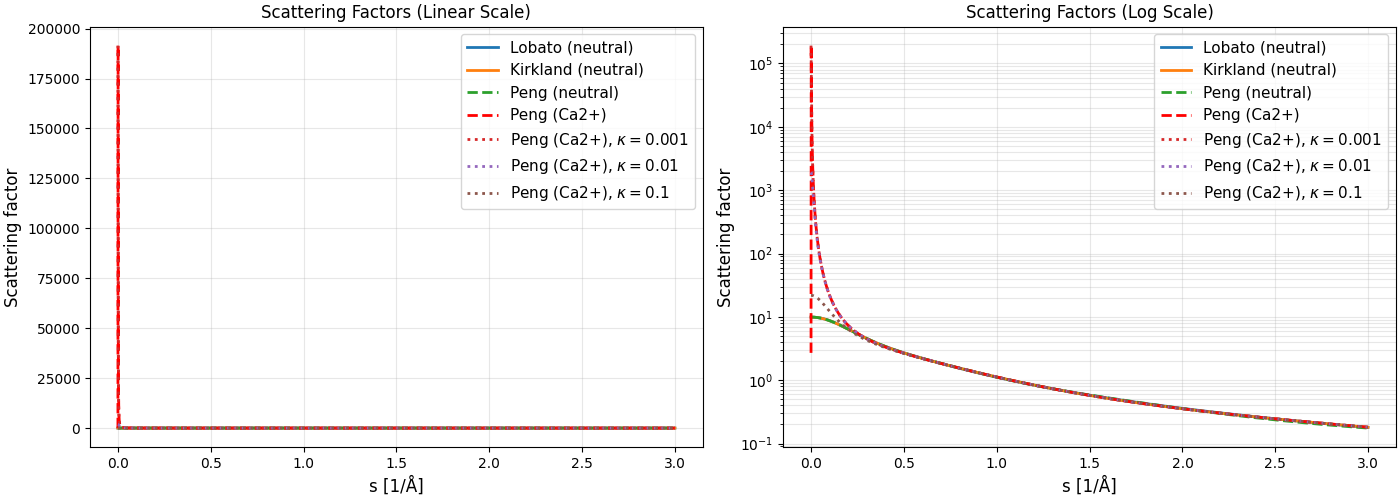

In [3]:
# Create parametrizations
lobato = LobatoParametrization()
kirkland = KirklandParametrization()
peng_neutral = PengParametrization('peng_high.json')
peng_ionic = PengParametrization('peng_ionic.json')

# Get scattering factors for Ca (neutral) and Ca2+ (ionic)
sampling_s = 1 / (2*L)
f_lobato_ca = lobato.line_profiles('Ca', cutoff=3, sampling=sampling_s, name='scattering_factor')
f_kirkland_ca = kirkland.line_profiles('Ca', cutoff=3, sampling=sampling_s, name='scattering_factor')
f_peng_ca_neutral = peng_neutral.line_profiles('Ca', cutoff=3, sampling=sampling_s, name='scattering_factor')
f_peng_ca_ionic = peng_ionic.line_profiles('Ca', charge=2.0, cutoff=3, sampling=sampling_s, name='scattering_factor')
f_peng_ca_ionic_kappa1em3 = peng_ionic.line_profiles('Ca', charge=2.0, cutoff=3, sampling=sampling_s, kappa=0.001, name='scattering_factor')
f_peng_ca_ionic_kappa1em2 = peng_ionic.line_profiles('Ca', charge=2.0, cutoff=3, sampling=sampling_s, kappa=0.01, name='scattering_factor')
f_peng_ca_ionic_kappa1em1 = peng_ionic.line_profiles('Ca', charge=2.0, cutoff=3, sampling=sampling_s, kappa=0.1, name='scattering_factor')
#f_peng_ca_ionic_Lcell = peng_ionic.line_profiles('Ca', charge=2.0, cutoff=3, sampling=sampling_s, regularization='rozzi_spherical', L_cell=L, name='scattering_factor')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout='constrained')

s = f_lobato_ca.axes_metadata[1].coordinates(f_lobato_ca.shape[-1])

# Linear scale
ax = axes[0]
ax.plot(s, f_lobato_ca.array[0, :], label='Lobato (neutral)', linewidth=2)
ax.plot(s, f_kirkland_ca.array[0, :], label='Kirkland (neutral)', linewidth=2)
ax.plot(s, f_peng_ca_neutral.array[0, :], label='Peng (neutral)', linewidth=2, linestyle='--')
ax.plot(s, f_peng_ca_ionic.array[0, :], label='Peng (Ca2+)', linewidth=2, linestyle='--', color='red')
ax.plot(s, f_peng_ca_ionic_kappa1em3.array[0, :], label=r'Peng (Ca2+), $\kappa = 0.001$', linewidth=2, linestyle=':')
ax.plot(s, f_peng_ca_ionic_kappa1em2.array[0, :], label=r'Peng (Ca2+), $\kappa = 0.01$', linewidth=2, linestyle=':')
ax.plot(s, f_peng_ca_ionic_kappa1em1.array[0, :], label=r'Peng (Ca2+), $\kappa = 0.1$', linewidth=2, linestyle=':')
#ax.plot(s, f_peng_ca_ionic_Lcell.array[0, :], label=fr'Peng (Ca2+), $L_{{\text{{cell}}}} = {L:.1f}$', linewidth=2, linestyle=':')
ax.set_xlabel('s [1/Å]', fontsize=12)
ax.set_ylabel('Scattering factor', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_title('Scattering Factors (Linear Scale)')

# Log scale
ax = axes[1]
ax.semilogy(s, f_lobato_ca.array[0, :], label='Lobato (neutral)', linewidth=2)
ax.semilogy(s, f_kirkland_ca.array[0, :], label='Kirkland (neutral)', linewidth=2)
ax.semilogy(s, f_peng_ca_neutral.array[0, :], label='Peng (neutral)', linewidth=2, linestyle='--')
ax.semilogy(s, f_peng_ca_ionic.array[0, :], label='Peng (Ca2+)', linewidth=2, linestyle='--', color='red')
ax.semilogy(s, f_peng_ca_ionic_kappa1em3.array[0, :], label=r'Peng (Ca2+), $\kappa = 0.001$', linewidth=2, linestyle=':')
ax.semilogy(s, f_peng_ca_ionic_kappa1em2.array[0, :], label=r'Peng (Ca2+), $\kappa = 0.01$', linewidth=2, linestyle=':')
ax.semilogy(s, f_peng_ca_ionic_kappa1em1.array[0, :], label=r'Peng (Ca2+), $\kappa = 0.1$', linewidth=2, linestyle=':')
#ax.semilogy(s, f_peng_ca_ionic_Lcell.array[0, :], label=fr'Peng (Ca2+), $L_{{\text{{cell}}}} = {L:.1f}$', linewidth=2, linestyle=':')
ax.set_xlabel('s [1/Å]', fontsize=12)
ax.set_ylabel('Scattering factor', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')
ax.set_title('Scattering Factors (Log Scale)')

plt.show()

In [9]:
atoms = Atoms(
    'Ca',
    charges=[0.0],
    cell=[L, L, 1],
    scaled_positions=[[0.5, 0.5, 0.5]],
    pbc=True,
)

# Create potential
potential = abtem.Potential(
    atoms,
    sampling=sampling,
    slice_thickness=1.0,
    projection='infinite',
    parametrization=PengParametrization('peng_high.json'),
)
potential.show(interact=True, cbar=True)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

ImageGUI(children=(VBox(children=(HBox(children=(Button(description='Reset sliders', style=ButtonStyle()), Tog…

In [10]:
atoms = Atoms(
    'Ca',
    charges=[2.0],
    cell=[L, L, 1],
    scaled_positions=[[0.5, 0.5, 0.5]],
    pbc=True,
)

# Create potential
potential = abtem.Potential(
    atoms,
    sampling=sampling,
    slice_thickness=1.0,
    projection='infinite',
    parametrization=PengParametrization('peng_ionic.json'),
)
potential.show(interact=True, cbar=True)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

ImageGUI(children=(VBox(children=(HBox(children=(Button(description='Reset sliders', style=ButtonStyle()), Tog…

In [11]:
atoms = Atoms(
    'Ca',
    charges=[2.0],
    cell=[L, L, 1],
    scaled_positions=[[0.5, 0.5, 0.5]],
    pbc=True,
)

# Create potential
potential = abtem.Potential(
    atoms,
    sampling=sampling,
    slice_thickness=1.0,
    projection='infinite',
    parametrization=PengParametrization('peng_ionic.json', regularization='rozzi_spherical', L_cell=L),
)
potential.show(interact=True, cbar=True)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

ImageGUI(children=(VBox(children=(HBox(children=(Button(description='Reset sliders', style=ButtonStyle()), Tog…

In [12]:
atoms = Atoms(
    'Ca',
    charges=[2.0],
    cell=[L, L, 1],
    scaled_positions=[[0.5, 0.5, 0.5]],
    pbc=True,
)

# Create potential
potential = abtem.Potential(
    atoms,
    sampling=sampling,
    slice_thickness=1.0,
    projection='infinite',
    parametrization=PengParametrization('peng_ionic.json', regularization='yukawa', L_cell=L),
)
potential.show(interact=True, cbar=True)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

ImageGUI(children=(VBox(children=(HBox(children=(Button(description='Reset sliders', style=ButtonStyle()), Tog…

In [15]:
atoms = Atoms(
    'Ca',
    charges=[2.0],
    cell=[L, L, 1],
    scaled_positions=[[0.5, 0.5, 0.5]],
    pbc=True,
)

# Create potential
potential = abtem.Potential(
    atoms,
    sampling=sampling,
    slice_thickness=1.0,
    projection='infinite',
    parametrization=PengParametrization('peng_ionic.json', regularization='yukawa', kappa=2*np.pi/L),
)
potential.show(interact=True, cbar=True)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

ImageGUI(children=(VBox(children=(HBox(children=(Button(description='Reset sliders', style=ButtonStyle()), Tog…

In [20]:
1/L

0.002

In [11]:
s[1]

np.float64(0.001)

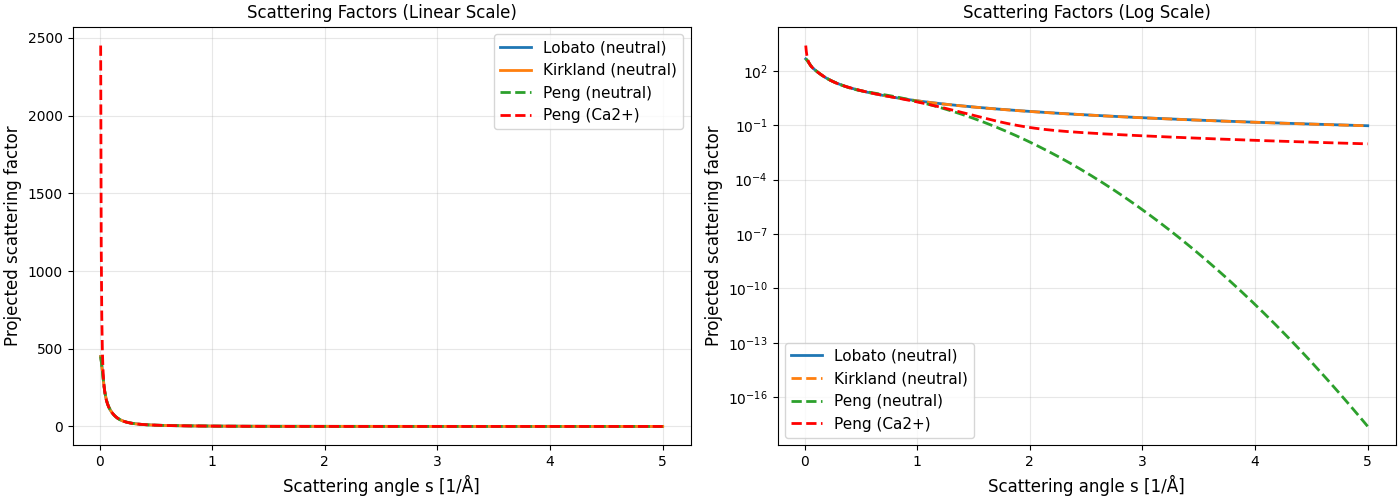

Difference between Peng neutral and Peng ionic at s=0.1 Å⁻¹:
  Neutral: 100.389349
  Ionic:   100.069271
  Diff:    0.320078


In [3]:
# Create parametrizations
lobato = LobatoParametrization()
kirkland = KirklandParametrization()
peng_neutral = PengParametrization('peng_high.json')
peng_ionic = PengParametrization('peng_ionic.json')

# Scattering angle range for plotting
cutoff = 5.0  # 1/Angstrom
s = np.linspace(0.01, cutoff, 1000)  # s = |k|/(4*pi) = reciprocal distance / (2*pi)
k2 = (2 * np.pi * s) ** 2

# Get scattering factors for Ca and Ca2+
f_lobato_ca = lobato.projected_scattering_factor('Ca', charge=0.0)(k2)
f_kirkland_ca = kirkland.projected_scattering_factor('Ca', charge=0.0)(k2)
f_peng_ca_neutral = peng_neutral.projected_scattering_factor('Ca', charge=0.0)(k2)
f_peng_ca_ionic = peng_ionic.projected_scattering_factor('Ca', charge=2.0)(k2)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout='constrained')

# Linear scale
ax = axes[0]
ax.plot(s, f_lobato_ca, label='Lobato (neutral)', linewidth=2)
ax.plot(s, f_kirkland_ca, label='Kirkland (neutral)', linewidth=2)
ax.plot(s, f_peng_ca_neutral, label='Peng (neutral)', linewidth=2, linestyle='--')
ax.plot(s, f_peng_ca_ionic, label='Peng (Ca2+)', linewidth=2, linestyle='--', color='red')
ax.set_xlabel('Scattering angle s [1/Å]', fontsize=12)
ax.set_ylabel('Projected scattering factor', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_title('Scattering Factors (Linear Scale)')

# Log scale (better for small angles)
ax = axes[1]
ax.semilogy(s, f_lobato_ca, label='Lobato (neutral)', linewidth=2)
ax.semilogy(s, f_kirkland_ca, label='Kirkland (neutral)', linewidth=2, linestyle='--')
ax.semilogy(s, f_peng_ca_neutral, label='Peng (neutral)', linewidth=2, linestyle='--')
ax.semilogy(s, f_peng_ca_ionic, label='Peng (Ca2+)', linewidth=2, linestyle='--', color='red')
ax.set_xlabel('Scattering angle s [1/Å]', fontsize=12)
ax.set_ylabel('Projected scattering factor', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')
ax.set_title('Scattering Factors (Log Scale)')
plt.show()

# Print differences
print(f"Difference between Peng neutral and Peng ionic at s=0.1 Å⁻¹:")
idx = np.argmin(np.abs(s - 0.1))
print(f"  Neutral: {f_peng_ca_neutral[idx]:.6f}")
print(f"  Ionic:   {f_peng_ca_ionic[idx]:.6f}")
print(f"  Diff:    {abs(f_peng_ca_neutral[idx] - f_peng_ca_ionic[idx]):.6f}")

## 2. Compare Electron Wave Functions

In [ ]:
def compute_wave(atom_symbol, charge, parametrization, energy=200, alpha=0.1, L=50, sampling=0.1):
    """
    Compute electron wave after scattering on a single atom.
    
    Parameters
    ----------
    atom_symbol : str
        Chemical symbol (e.g., 'Ca')
    charge : float
        Charge in elementary units (e.g., 2.0 for Ca2+)
    parametrization : str or Parametrization
        Scattering factor parametrization
    energy : float
        Beam energy in eV
    alpha : float
        Semi-angle cutoff in mrad
    L : float
        Supercell size in Angstrom
    sampling : float
        Real-space sampling in Angstrom
    
    Returns
    -------
    wave : ndarray
        Complex wave function
    intensity : ndarray
        Wave intensity
    """
    # Create probe and atoms
    probe = abtem.Probe(energy=energy, semiangle_cutoff=alpha)
    
    atoms = Atoms(
        atom_symbol,
        charges=[charge],
        cell=[L, L, 1],
        scaled_positions=[[0.5, 0.5, 0.5]],
        pbc=True,
    )
    
    # Create potential
    potential = abtem.Potential(
        atoms,
        sampling=sampling,
        slice_thickness=1.0,
        projection='infinite',
        parametrization=parametrization,
    )

    print(potential.extent)
    
    # Create scan at center
    scan = abtem.GridScan(
        (0.5, 0.5),
        end=(1., 1.0),
        fractional=True,
        potential=potential,
        sampling=potential.extent,
    )
    
    # Run multislice
    detectors = [abtem.WavesDetector()]
    wave = probe.scan(
        potential=potential,
        scan=scan,
        detectors=detectors,
        max_batch=1,
    ).compute()

    wave = wave.to_cpu()
    
    return wave, wave.intensity().compute()

print("Computing waves for Ca (neutral)...")
wave_neutral, intensity_neutral = compute_wave(
    'Ca', 0.0, PengParametrization('peng_high.json'),
    energy=energy, alpha=alpha, L=L, sampling=sampling
)

print("Computing waves for Ca2+ (ionic)...")
wave_ionic, intensity_ionic = compute_wave(
    'Ca', 2.0, PengParametrization('peng_ionic.json'),
    energy=energy, alpha=alpha, L=L, sampling=sampling
)

# Extract 2D slices from the scan results (shape is (scan_y, scan_x, ny, nx))
intensity_neutral = intensity_neutral.array[0, 0]
intensity_ionic = intensity_ionic.array[0, 0]
wave_neutral = wave_neutral.array[0, 0]
wave_ionic = wave_ionic.array[0, 0]

print(f"Wave shapes: {wave_neutral.shape}")
print(f"Neutral wave intensity range: [{intensity_neutral.min():.4e}, {intensity_neutral.max():.4e}]")
print(f"Ionic wave intensity range:   [{intensity_ionic.min():.4e}, {intensity_ionic.max():.4e}]")

## 3. Visualize Wave Functions and Differences

In [ ]:
# Create comparison plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10), layout='constrained')

# Neutral wave intensity
im0 = axes[0, 0].imshow(intensity_neutral, cmap='viridis')
axes[0, 0].set_title('Neutral Ca - Intensity', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('x (pixels)')
axes[0, 0].set_ylabel('y (pixels)')
plt.colorbar(im0, ax=axes[0, 0])

# Ionic wave intensity
im1 = axes[0, 1].imshow(intensity_ionic, cmap='viridis')
axes[0, 1].set_title('Ionic Ca2+ - Intensity', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('x (pixels)')
axes[0, 1].set_ylabel('y (pixels)')
plt.colorbar(im1, ax=axes[0, 1])

# Difference in intensity
intensity_diff = intensity_neutral - intensity_ionic
im2 = axes[0, 2].imshow(intensity_diff, cmap='RdBu_r')
axes[0, 2].set_title('Intensity Difference (Neutral - Ionic)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('x (pixels)')
axes[0, 2].set_ylabel('y (pixels)')
plt.colorbar(im2, ax=axes[0, 2])

# Neutral phase
phase_neutral = np.angle(wave_neutral)
im3 = axes[1, 0].imshow(phase_neutral, cmap='hsv')
axes[1, 0].set_title('Neutral Ca - Phase', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('x (pixels)')
axes[1, 0].set_ylabel('y (pixels)')
plt.colorbar(im3, ax=axes[1, 0])

# Ionic phase
phase_ionic = np.angle(wave_ionic)
im4 = axes[1, 1].imshow(phase_ionic, cmap='hsv')
axes[1, 1].set_title('Ionic Ca2+ - Phase', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('x (pixels)')
axes[1, 1].set_ylabel('y (pixels)')
plt.colorbar(im4, ax=axes[1, 1])

# Phase difference
phase_diff = phase_neutral - phase_ionic
im5 = axes[1, 2].imshow(phase_diff, cmap='RdBu_r')
axes[1, 2].set_title('Phase Difference (Neutral - Ionic)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('x (pixels)')
axes[1, 2].set_ylabel('y (pixels)')
plt.colorbar(im5, ax=axes[1, 2])

plt.show()

## 4. Quantitative Comparison

In [5]:
# Compute statistics
intensity_neutral_sum = intensity_neutral.sum()
intensity_ionic_sum = intensity_ionic.sum()

print("=" * 60)
print("WAVE FUNCTION COMPARISON: NEUTRAL CA vs CA2+")
print("=" * 60)

print(f"\nIntensity Statistics:")
print(f"  Neutral sum:     {intensity_neutral_sum:.6e}")
print(f"  Ionic sum:       {intensity_ionic_sum:.6e}")
print(f"  Relative diff:   {abs(intensity_neutral_sum - intensity_ionic_sum) / intensity_neutral_sum * 100:.2f}%")

print(f"\nIntensity Peak Values:")
print(f"  Neutral max:     {intensity_neutral.max():.6e}")
print(f"  Ionic max:       {intensity_ionic.max():.6e}")
print(f"  Relative diff:   {abs(intensity_neutral.max() - intensity_ionic.max()) / intensity_neutral.max() * 100:.2f}%")

print(f"\nPhase Statistics:")
# Only compute phase difference where intensities are non-negligible
mask = (intensity_neutral > intensity_neutral.max() * 0.01) | (intensity_ionic > intensity_ionic.max() * 0.01)
phase_diff_masked = phase_diff[mask]
print(f"  Mean phase diff: {np.mean(phase_diff_masked):.6f} rad")
print(f"  Std phase diff:  {np.std(phase_diff_masked):.6f} rad")
print(f"  Max phase diff:  {np.max(np.abs(phase_diff_masked)):.6f} rad")

print(f"\nIntensity Difference (RMS):")
rms_intensity_diff = np.sqrt(np.mean(intensity_diff ** 2))
print(f"  RMS:             {rms_intensity_diff:.6e}")
print(f"  Relative to neutral avg: {rms_intensity_diff / intensity_neutral.mean() * 100:.2f}%")

print("\n" + "=" * 60)

WAVE FUNCTION COMPARISON: NEUTRAL CA vs CA2+

Intensity Statistics:
  Neutral sum:     3.999988e-08
  Ionic sum:       3.999992e-08
  Relative diff:   0.00%

Intensity Peak Values:
  Neutral max:     9.275306e-13
  Ionic max:       8.831133e-13
  Relative diff:   4.79%

Phase Statistics:
  Mean phase diff: 0.000129 rad
  Std phase diff:  0.002442 rad
  Max phase diff:  0.194494 rad

Intensity Difference (RMS):
  RMS:             1.213276e-17
  Relative to neutral avg: 0.76%



## 5. 1D Line Profiles

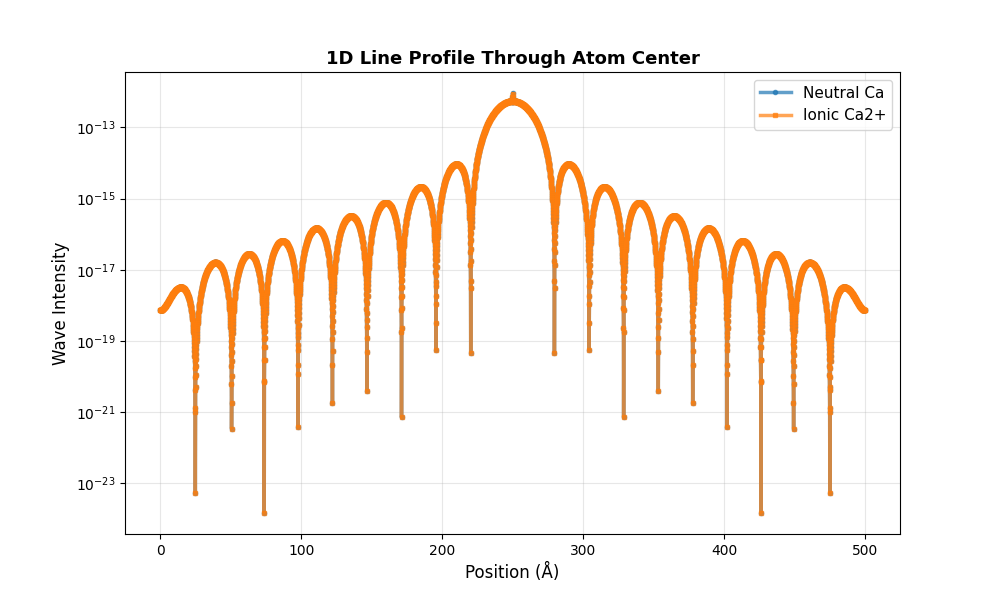

In [6]:
# Extract line profiles through the center
center = intensity_neutral.shape[0] // 2

line_neutral = intensity_neutral[center, :]
line_ionic = intensity_ionic[center, :]
x_coords = np.arange(len(line_neutral)) * sampling

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(x_coords, line_neutral, label='Neutral Ca', linewidth=2.5, marker='o', markersize=3, alpha=0.7)
ax.semilogy(x_coords, line_ionic, label='Ionic Ca2+', linewidth=2.5, marker='s', markersize=3, alpha=0.7)
ax.set_xlabel('Position (Å)', fontsize=12)
ax.set_ylabel('Wave Intensity', fontsize=12)
ax.set_title('1D Line Profile Through Atom Center', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.show()